# 裂纹图像识别系统 —— 数据处理与传统监督学习方法专题报告

> 《机器学习与 Python 编程》研究性专题 · 数据处理方法 & 传统监督方法方向  
> 本报告聚焦 **数据读取、图像预处理、手工特征工程、数据划分**，以及 **SVM、朴素贝叶斯、逻辑回归** 三类传统监督学习方法。  
> 报告将核心流程、关键代码、参数含义和实验结果整合在同一个 Notebook 中，便于独立阅读和复现实验思路。

---

## 报告摘要

本项目任务为表面裂纹图像二分类：`1` 表示有裂纹，`0` 表示无裂纹。数据集共 **40,000 张** `.jpg` 图像，其中有裂纹与无裂纹样本各 **20,000 张**，类别天然均衡。传统监督学习部分不直接端到端学习图像，而是先将灰度图转换为 **HOG + LBP + GLCM + 边缘密度** 的手工特征，再输入监督分类器。

| 维度 | 结论 |
|------|------|
| 数据分布 | 正负样本完全均衡，Accuracy、F1、ROC-AUC 都有解释意义 |
| 数据处理 | 分层划分稳定；预处理方法差异较小，应结合验证结果选择 |
| 特征工程 | GLCM 纹理统计贡献突出，多特征组合提供更稳健表示 |
| 传统模型 | SVM 与逻辑回归 Test F1 均为 **0.9371**，朴素贝叶斯为 **0.9080** |
| 工程选择 | 逻辑回归速度快且可解释，SVM 稳定但耗时长，朴素贝叶斯适合作为轻量基线 |


## 一、数据集与统一实验设置

### 1.1 数据集结构

- **任务**：表面裂纹图像二分类（`1` = 有裂纹 / Positive，`0` = 无裂纹 / Negative）
- **规模**：共 **40,000 张** `.jpg` 图像，正负样本各 **20,000** 张
- **评价指标**：Accuracy、Precision、Recall、F1、ROC-AUC

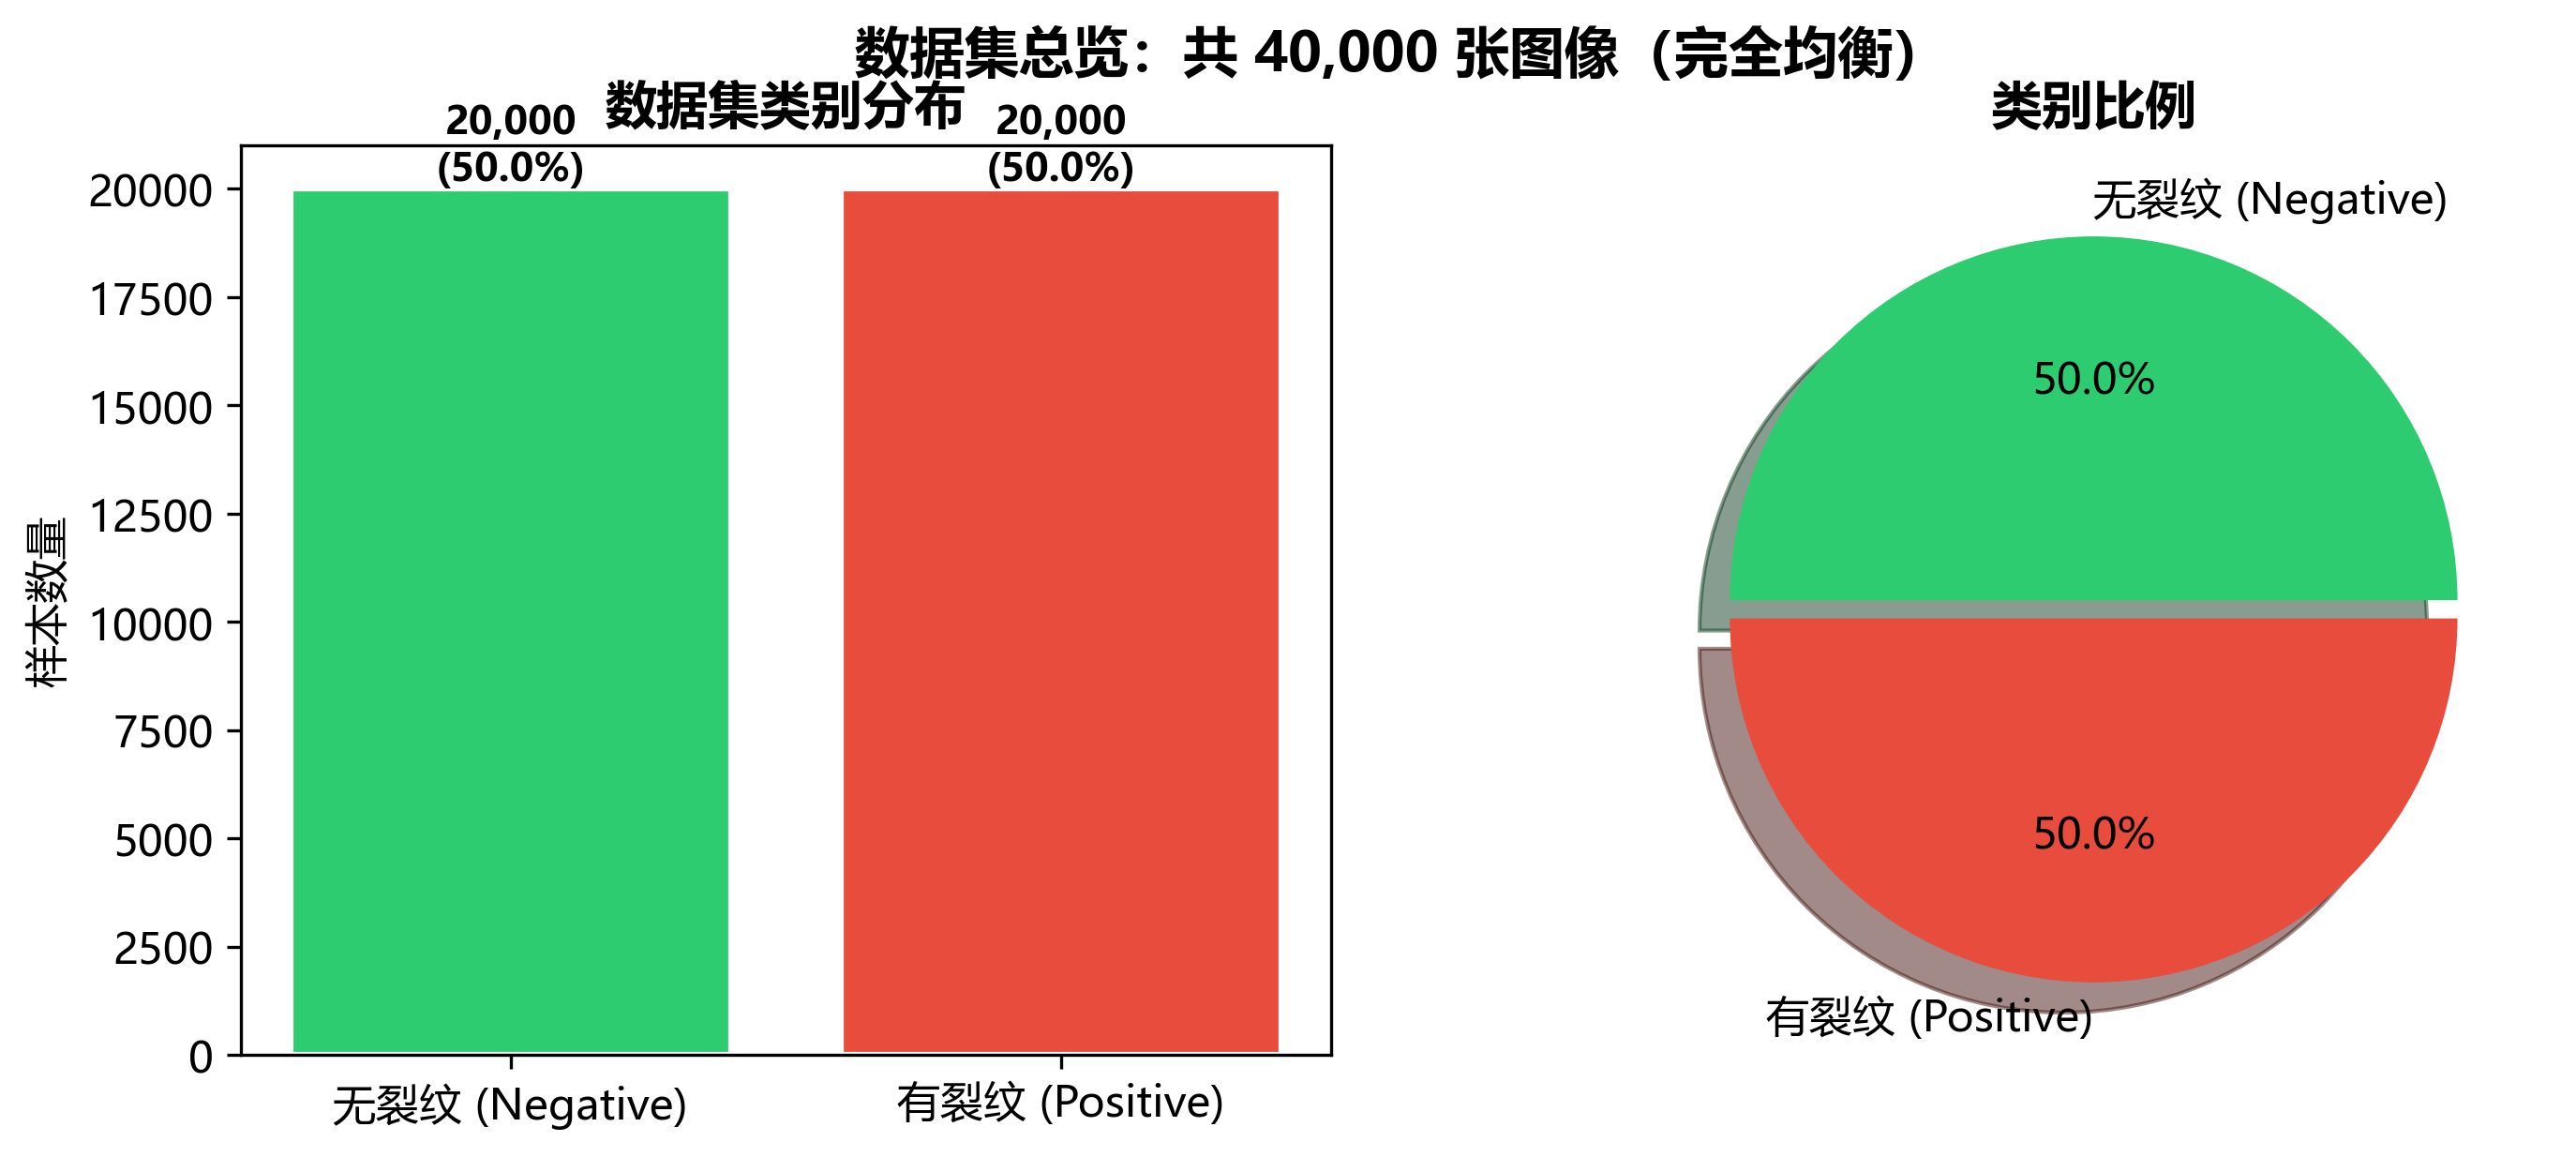

### 1.2 统一实验流程

传统监督学习部分采用同一套处理流程，保证模型比较公平：

> 图像读取 → 灰度预处理 → HOG/LBP/GLCM/边缘密度特征提取 → 分层训练测试划分 → 标准化 → 模型训练与交叉验证 → 测试集评估

为了避免打开 Notebook 时自动重跑耗时较长的全量网格搜索，本文将已完成的全量实验结果直接整理在表格中；代码单元保留完整训练流程，读者可以将 `RUN_FULL_EXPERIMENT` 改为 `True` 后在较小样本上复现实验。


In [ ]:
# 0. 环境配置与实验结果表
from pathlib import Path
import pandas as pd

# 当前 Notebook 默认不自动重跑训练，避免 SVM 网格搜索耗时过长。
# 如需验证代码流程，可将 RUN_FULL_EXPERIMENT 改为 True，并使用 QUICK_SAMPLES 控制样本数。
RUN_FULL_EXPERIMENT = False
QUICK_SAMPLES = 1000

# 全量实验结果直接写入 Notebook，保证报告作为单文件也能独立阅读。
traditional_results = pd.DataFrame([
    {"model": "xgboost", "cv_f1": 0.9715, "test_f1": 0.9497, "test_auc": 0.9816, "time_s": 165.2},
    {"model": "random_forest", "cv_f1": 0.9495, "test_f1": 0.9438, "test_auc": 0.9928, "time_s": 6.8},
    {"model": "lightgbm", "cv_f1": 0.9738, "test_f1": 0.9438, "test_auc": 0.9860, "time_s": 96.0},
    {"model": "svm", "cv_f1": 0.9457, "test_f1": 0.9371, "test_auc": 0.9865, "time_s": 121.8},
    {"model": "logistic_regression", "cv_f1": 0.9665, "test_f1": 0.9371, "test_auc": 0.9911, "time_s": 3.2},
    {"model": "decision_tree", "cv_f1": 0.9334, "test_f1": 0.9180, "test_auc": 0.9167, "time_s": 18.7},
    {"model": "naive_bayes", "cv_f1": 0.9059, "test_f1": 0.9080, "test_auc": 0.9478, "time_s": 0.9},
])

traditional_results


## 二、数据读取与处理工作流

本节目标是把原始图像转化为机器学习模型可用的 `(X_train, X_test, y_train, y_test)`。

工作流如下：

1. 用 `_imread_gray()` 读取灰度图，避免中文路径导致 OpenCV 直接读取失败。
2. 用 `load_dataset()` 从有裂纹和无裂纹两个类别目录构造图像数组与标签。
3. 用 CLAHE、Gaussian、Median 等函数做图像增强或去噪。
4. 用 HOG、LBP、GLCM、边缘密度提取手工特征。
5. 在 `prepare_data()` 中完成预处理、特征拼接和分层划分。


In [ ]:
# 1. 数据读取与图像预处理核心代码
import cv2
import numpy as np
from pathlib import Path
from typing import Optional, Tuple

# 允许读取的图像后缀，避免把说明文件或隐藏文件误当作图片。
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

def _imread_gray(path: Path) -> Optional[np.ndarray]:
    """以灰度模式读取图像。"""
    # np.fromfile()：先按字节读取文件，可兼容包含中文字符的本地路径。
    # dtype=np.uint8：图像文件是 0~255 的字节流，需按无符号 8 位整数读取。
    buf = np.fromfile(str(path), dtype=np.uint8)
    if buf is None or buf.size == 0:
        return None

    # cv2.imdecode()：把字节流解码为图像矩阵。
    # cv2.IMREAD_GRAYSCALE：直接解码为单通道灰度图，降低后续手工特征维度。
    return cv2.imdecode(buf, cv2.IMREAD_GRAYSCALE)

def load_dataset(data_root: Path, max_samples: int = None):
    """加载二分类图像数据，返回 images 和 labels。"""
    def _load_dir(directory: Path, label: int, limit: int = None):
        imgs, lbls = [], []
        paths = sorted(directory.iterdir())

        # limit：限制每类读取数量，便于快速验证；正式实验可设为 None 使用全量数据。
        for path in paths[:limit]:
            if path.suffix.lower() in IMAGE_EXTS:
                img = _imread_gray(path)
                if img is not None:
                    imgs.append(img)
                    lbls.append(label)
        return imgs, lbls

    # max_samples 平均分给正负两类，保证快速实验时类别仍然均衡。
    n_per = max_samples // 2 if max_samples else None
    pos_imgs, pos_lbls = _load_dir(data_root / "Positive", label=1, limit=n_per)
    neg_imgs, neg_lbls = _load_dir(data_root / "Negative", label=0, limit=n_per)

    all_imgs = pos_imgs + neg_imgs
    labels = np.array(pos_lbls + neg_lbls, dtype=np.int64)

    # 如果图像尺寸一致，用 np.stack 得到规则四维/三维数组；否则保留 object 数组。
    shapes = {img.shape for img in all_imgs}
    images = np.stack(all_imgs) if len(shapes) == 1 else np.array(all_imgs, dtype=object)
    return images, labels

def apply_clahe(
    image: np.ndarray,
    clip_limit: float = 2.0,
    tile_grid_size: Tuple[int, int] = (8, 8),
) -> np.ndarray:
    """CLAHE 自适应直方图均衡化，用于增强局部对比度。"""
    # clipLimit：限制局部直方图放大幅度，值越大增强越强，也越可能放大噪声。
    # tileGridSize：把图像划分为多少个局部网格，(8,8) 是常用平衡设置。
    clahe_obj = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe_obj.apply(image)

def apply_gaussian_filter(
    image: np.ndarray,
    kernel_size: Tuple[int, int] = (5, 5),
    sigma: float = 1.0,
) -> np.ndarray:
    """高斯滤波，用于平滑随机噪声。"""
    # kernel_size：卷积核大小，必须为正奇数；越大平滑越强，细裂纹也更容易被抹掉。
    # sigma：高斯分布标准差，控制邻域像素权重衰减速度。
    return cv2.GaussianBlur(image, kernel_size, sigma)

def apply_median_filter(image: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    """中值滤波，用邻域中位数替代中心像素，适合抑制椒盐噪声。"""
    # kernel_size：邻域窗口大小，必须为奇数；窗口越大去噪越强，但纹理细节损失也越明显。
    return cv2.medianBlur(image, kernel_size)


In [ ]:
# 2. 手工特征提取核心代码（HOG + LBP + GLCM + 边缘密度）
from skimage.feature import hog, local_binary_pattern
from skimage.feature import graycomatrix, graycoprops

def extract_hog_features(
    image: np.ndarray,
    orientations: int = 9,
    pixels_per_cell: Tuple[int, int] = (8, 8),
    cells_per_block: Tuple[int, int] = (2, 2),
) -> np.ndarray:
    """HOG 方向梯度直方图，用于描述裂纹边缘方向和梯度结构。"""
    return hog(
        image,
        orientations=orientations,          # 梯度方向分箱数；9 表示把 0~180 度划分为 9 个方向。
        pixels_per_cell=pixels_per_cell,    # 每个 cell 的像素大小；越小越细致，维度也越高。
        cells_per_block=cells_per_block,    # 每个 block 包含的 cell 数；用于局部归一化，增强光照鲁棒性。
        feature_vector=True,                # 输出一维向量，便于与其他特征拼接后输入 sklearn 模型。
    )

def extract_lbp_features(
    image: np.ndarray,
    radius: int = 1,
    n_points: int = 8,
) -> np.ndarray:
    """LBP 局部二值模式，用于描述局部纹理变化。"""
    # radius：邻域半径；半径越大，捕获纹理范围越大。
    # n_points：采样点个数；通常取 8 * radius，这里 radius=1 时取 8 个邻点。
    # method="uniform"：使用 uniform LBP，能减少维度并突出常见纹理模式。
    n_bins = n_points * (n_points - 1) + 3
    lbp_image = local_binary_pattern(image, n_points, radius, method="uniform")
    hist, _ = np.histogram(
        lbp_image,
        bins=n_bins,        # 直方图桶数，对应 uniform LBP 的模式数量。
        range=(0, n_bins),  # 统计 LBP 编码值范围。
        density=True,       # 归一化为概率分布，减少图像大小对特征的影响。
    )
    return hist

def extract_glcm_features(
    image: np.ndarray,
    distances: Tuple[int, ...] = (1, 3, 5),
    angles: Tuple[float, ...] = (0, np.pi / 4, np.pi / 2, 3 * np.pi / 4),
) -> np.ndarray:
    """GLCM 灰度共生矩阵特征，用于描述灰度纹理的空间共现关系。"""
    img_u8 = image.astype(np.uint8) if image.dtype != np.uint8 else image
    props = []
    for d in distances:
        for a in angles:
            glcm = graycomatrix(
                img_u8,
                distances=[d],   # 像素对距离；1/3/5 分别描述近邻到稍远的纹理关系。
                angles=[a],      # 像素对方向；0、45、90、135 度覆盖主要纹理方向。
                levels=256,      # 灰度级数量；uint8 灰度图范围为 0~255，所以取 256。
                symmetric=True,  # 统计 (i,j) 同时合并 (j,i)，减弱方向顺序影响。
                normed=True,     # 归一化共生矩阵，使其可被不同图像间比较。
            )
            props.extend([
                graycoprops(glcm, "contrast")[0, 0],     # 对比度：灰度差异越大值越高。
                graycoprops(glcm, "correlation")[0, 0],  # 相关性：相邻灰度线性相关程度。
                graycoprops(glcm, "energy")[0, 0],       # 能量：纹理分布是否集中、规则。
                graycoprops(glcm, "homogeneity")[0, 0],  # 同质性：灰度越平滑值越高。
            ])
    return np.array(props, dtype=np.float64)

def extract_edge_density(
    image: np.ndarray,
    low_threshold: float = 50,
    high_threshold: float = 150,
) -> float:
    """边缘密度，衡量图像中边缘像素所占比例。"""
    # low_threshold/high_threshold：Canny 双阈值；低于低阈值丢弃，高于高阈值保留，中间区域按连通性判断。
    edges = cv2.Canny(image, low_threshold, high_threshold)
    return float(np.count_nonzero(edges)) / edges.size

def extract_features_separate(image: np.ndarray) -> dict:
    """分别提取四类特征，便于做特征组合对比。"""
    return {
        "hog": extract_hog_features(image),
        "lbp": extract_lbp_features(image),
        "glcm": extract_glcm_features(image),
        "edge_density": np.array([extract_edge_density(image)]),
    }


### 2.1 数据划分策略对比

数据划分部分在项目中承担两个作用：一是确保训练/测试集样本比例合理，二是保证后续模型比较公平。项目对比了不同留出比例与分层 K 折交叉验证，结果如下。

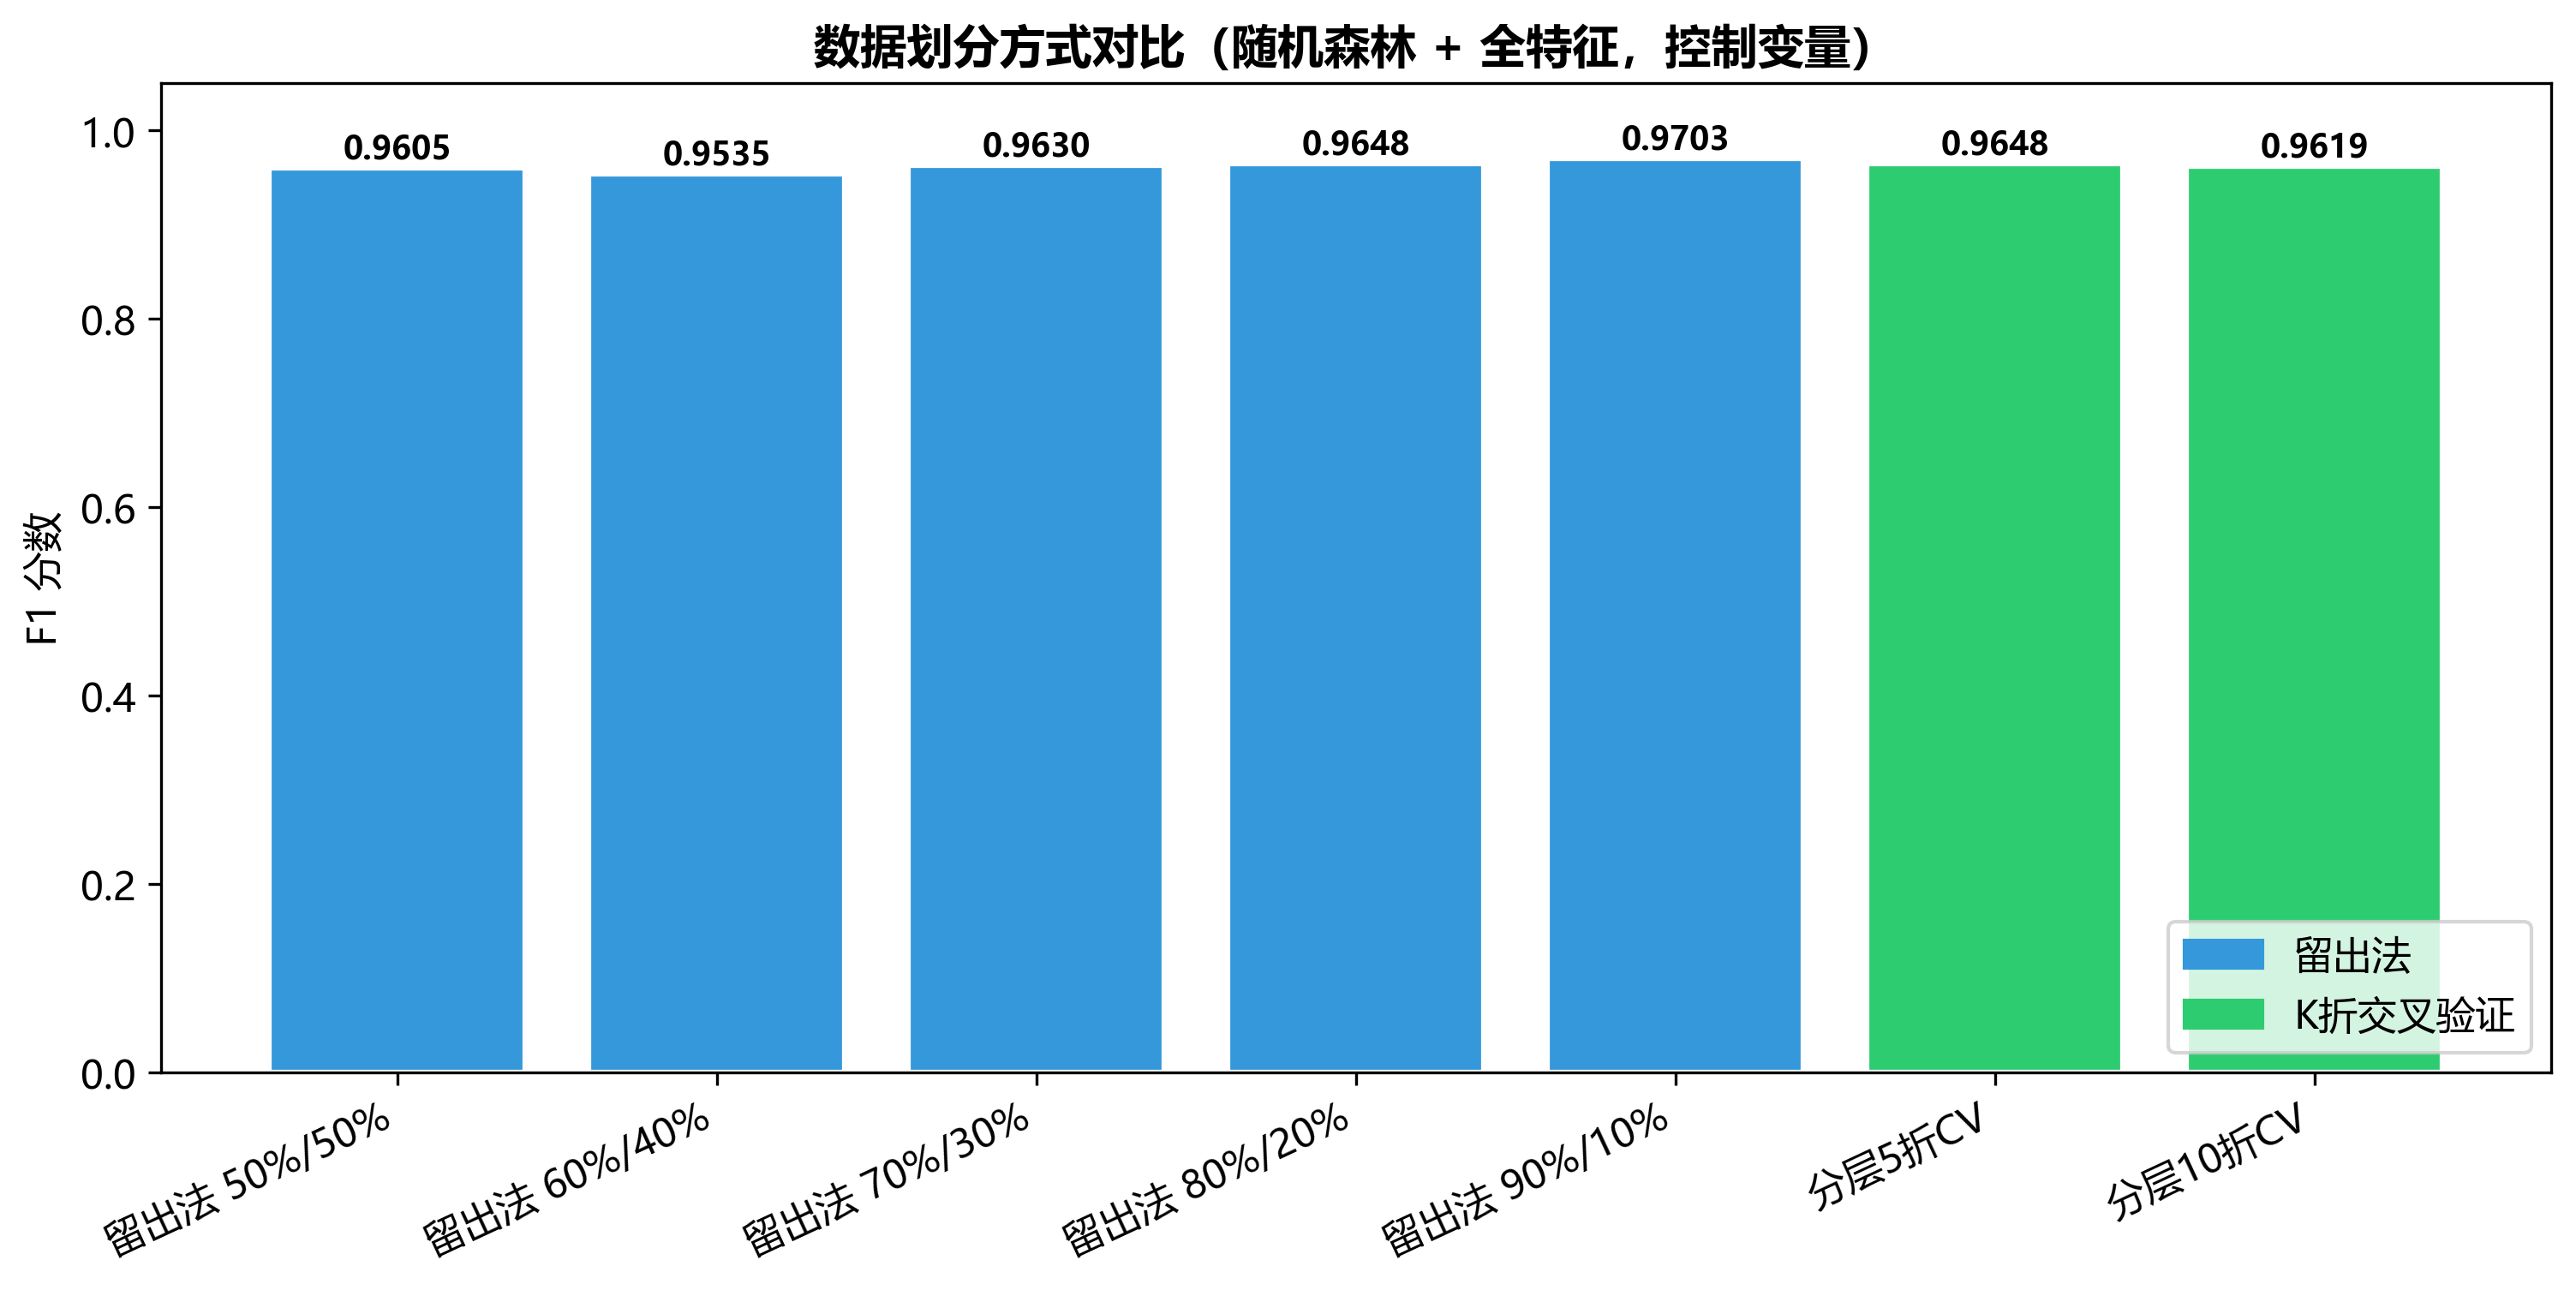

| 策略 | 类别 | Accuracy | F1 |
| --- | --- | --- | --- |
| 留出法 50%/50% | 留出法 | 0.9600 | 0.9605 |
| 留出法 60%/40% | 留出法 | 0.9525 | 0.9535 |
| 留出法 70%/30% | 留出法 | 0.9633 | 0.9630 |
| 留出法 80%/20% | 留出法 | 0.9650 | 0.9648 |
| 留出法 90%/10% | 留出法 | 0.9700 | 0.9703 |
| 分层5折CV | K折交叉验证 | 0.9650 | 0.9648 |
| 分层10折CV | K折交叉验证 | 0.9620 | 0.9619 |

从结果看，不同划分策略 F1 均稳定在约 0.95–0.97 区间。留出法 70/30 的 F1 为 **0.9630**，分层 5 折 CV 的 F1 为 **0.9648**。因此后续实验统一采用分层思想，兼顾稳定性与效率。


In [ ]:
# 3. prepare_data：把读取、预处理、特征提取、划分整合成一个可复用工作流
from sklearn.model_selection import train_test_split

def prepare_data(
    max_samples: int = 1000,
    random_seed: int = 42,
    split_ratio: float = 0.7,
    preprocessing: list = None,
    features: list = None,
    use_stratify: bool = True,
) -> dict:
    """统一数据管线：加载 → 预处理 → 提特征 → 分层划分。"""
    if preprocessing is None:
        preprocessing = ["clahe", "median"]
    if features is None:
        features = ["hog", "lbp", "glcm", "edge_density"]

    data_root = Path("data")
    images, labels = load_dataset(data_root, max_samples=max_samples)

    pipeline_map = {
        "none": lambda img: img,
        "clahe": lambda img: apply_clahe(img),
        "gaussian": lambda img: apply_gaussian_filter(img),
        "median": lambda img: apply_median_filter(img),
        "clahe+gaussian": lambda img: apply_gaussian_filter(apply_clahe(img)),
        "clahe+median": lambda img: apply_median_filter(apply_clahe(img)),
    }

    def compose_preprocess(img):
        for p in preprocessing:
            if p in pipeline_map and p != "none":
                img = pipeline_map[p](img)
        return img

    feat_map = {
        "hog": extract_hog_features,
        "lbp": extract_lbp_features,
        "glcm": extract_glcm_features,
        "edge_density": lambda img: np.array([extract_edge_density(img)]),
    }

    def extract_selected(img):
        parts = [feat_map[f](img) for f in features if f in feat_map]
        return np.concatenate(parts)

    processed = np.array([compose_preprocess(img) for img in images])
    X_all = np.stack([extract_selected(img) for img in processed])
    y_all = labels

    # train_test_split 参数说明：
    # test_size：测试集比例；split_ratio=0.7 时，test_size=0.3。
    # random_state：固定随机种子，保证每次划分可复现。
    # stratify：按类别分层抽样，保证训练集和测试集正负比例一致。
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all,
        test_size=round(1.0 - split_ratio, 4),
        random_state=random_seed,
        stratify=y_all if use_stratify else None,
    )

    return {
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "config": {
            "preprocessing": preprocessing,
            "features": features,
            "split_ratio": split_ratio,
            "n_samples": len(labels),
            "feature_dim": X_train.shape[1],
        },
    }

if RUN_FULL_EXPERIMENT:
    data = prepare_data(max_samples=QUICK_SAMPLES)
    data["config"]
else:
    print("默认不重跑特征提取；本报告使用 results 中的已验证全量结果。")


## 三、预处理与特征工程结果

### 3.1 预处理方法

预处理的目标是增强裂纹边缘、抑制噪声，并尽量保留纹理结构。实验中对比了 CLAHE、高斯滤波、中值滤波及组合方案。结果显示各预处理方案差异不大，不能简单说某一种方法绝对最优，更合理的结论是：**预处理对模型性能有辅助作用，滤波类方法在当前实验口径下略占优，CLAHE+滤波组合能在对比度增强和噪声抑制之间取得折中**。

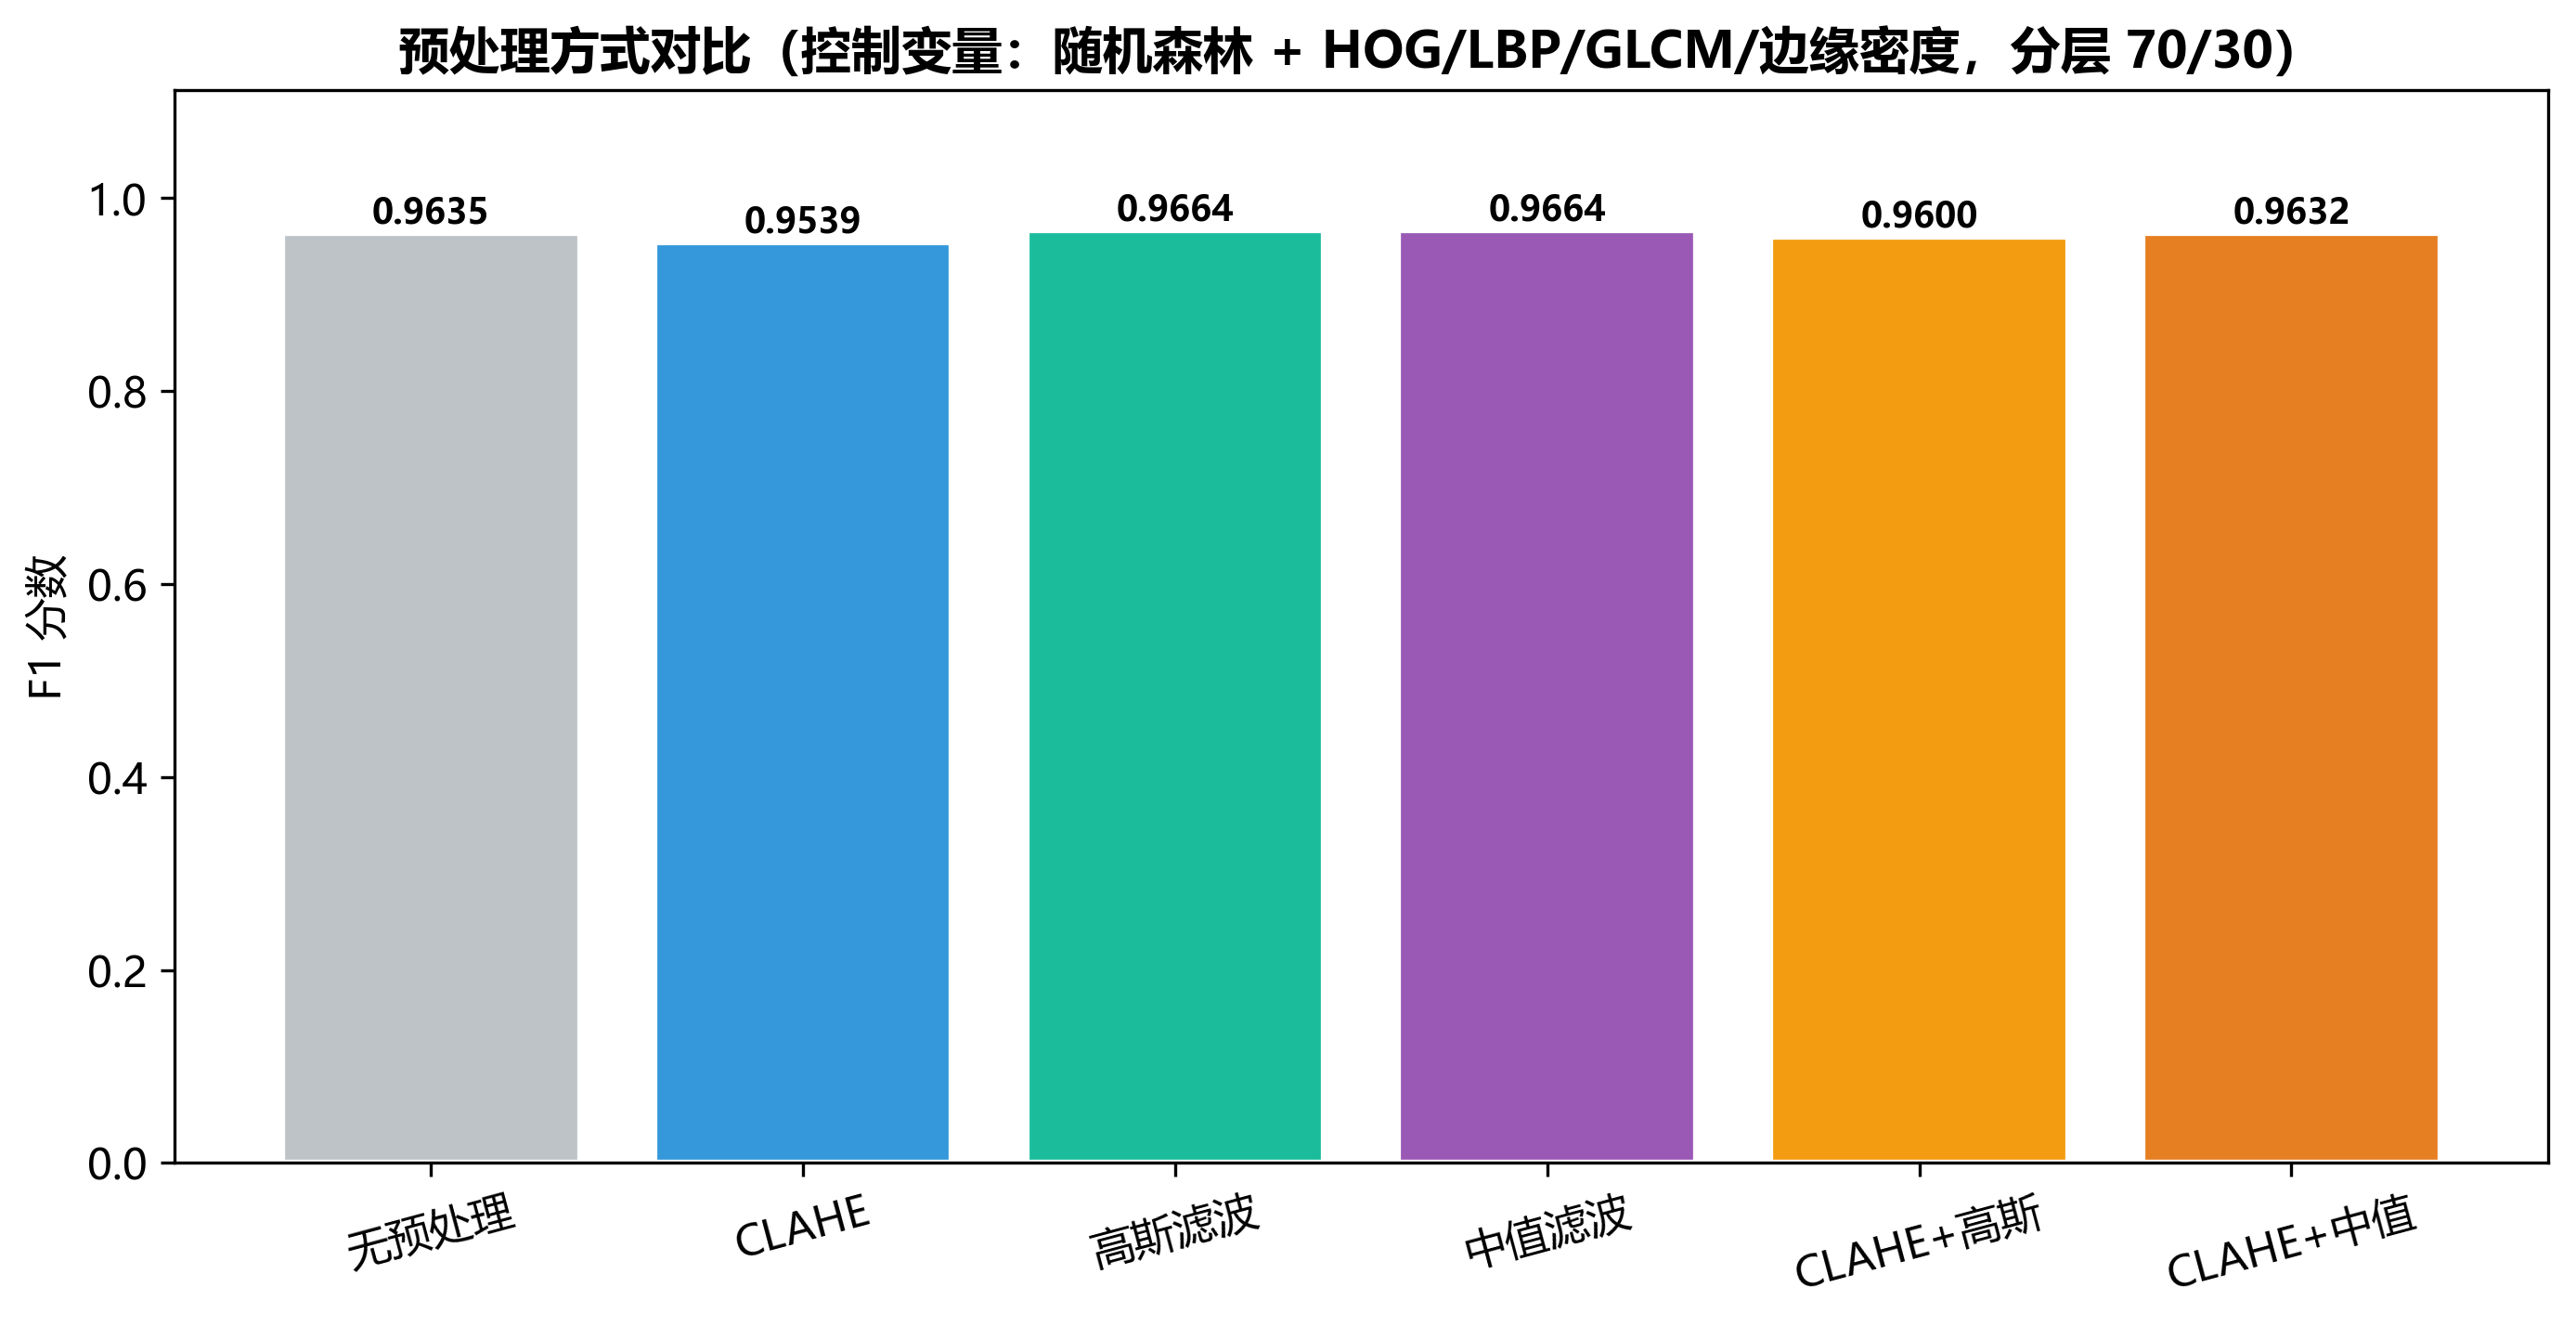

### 3.2 特征组合结果

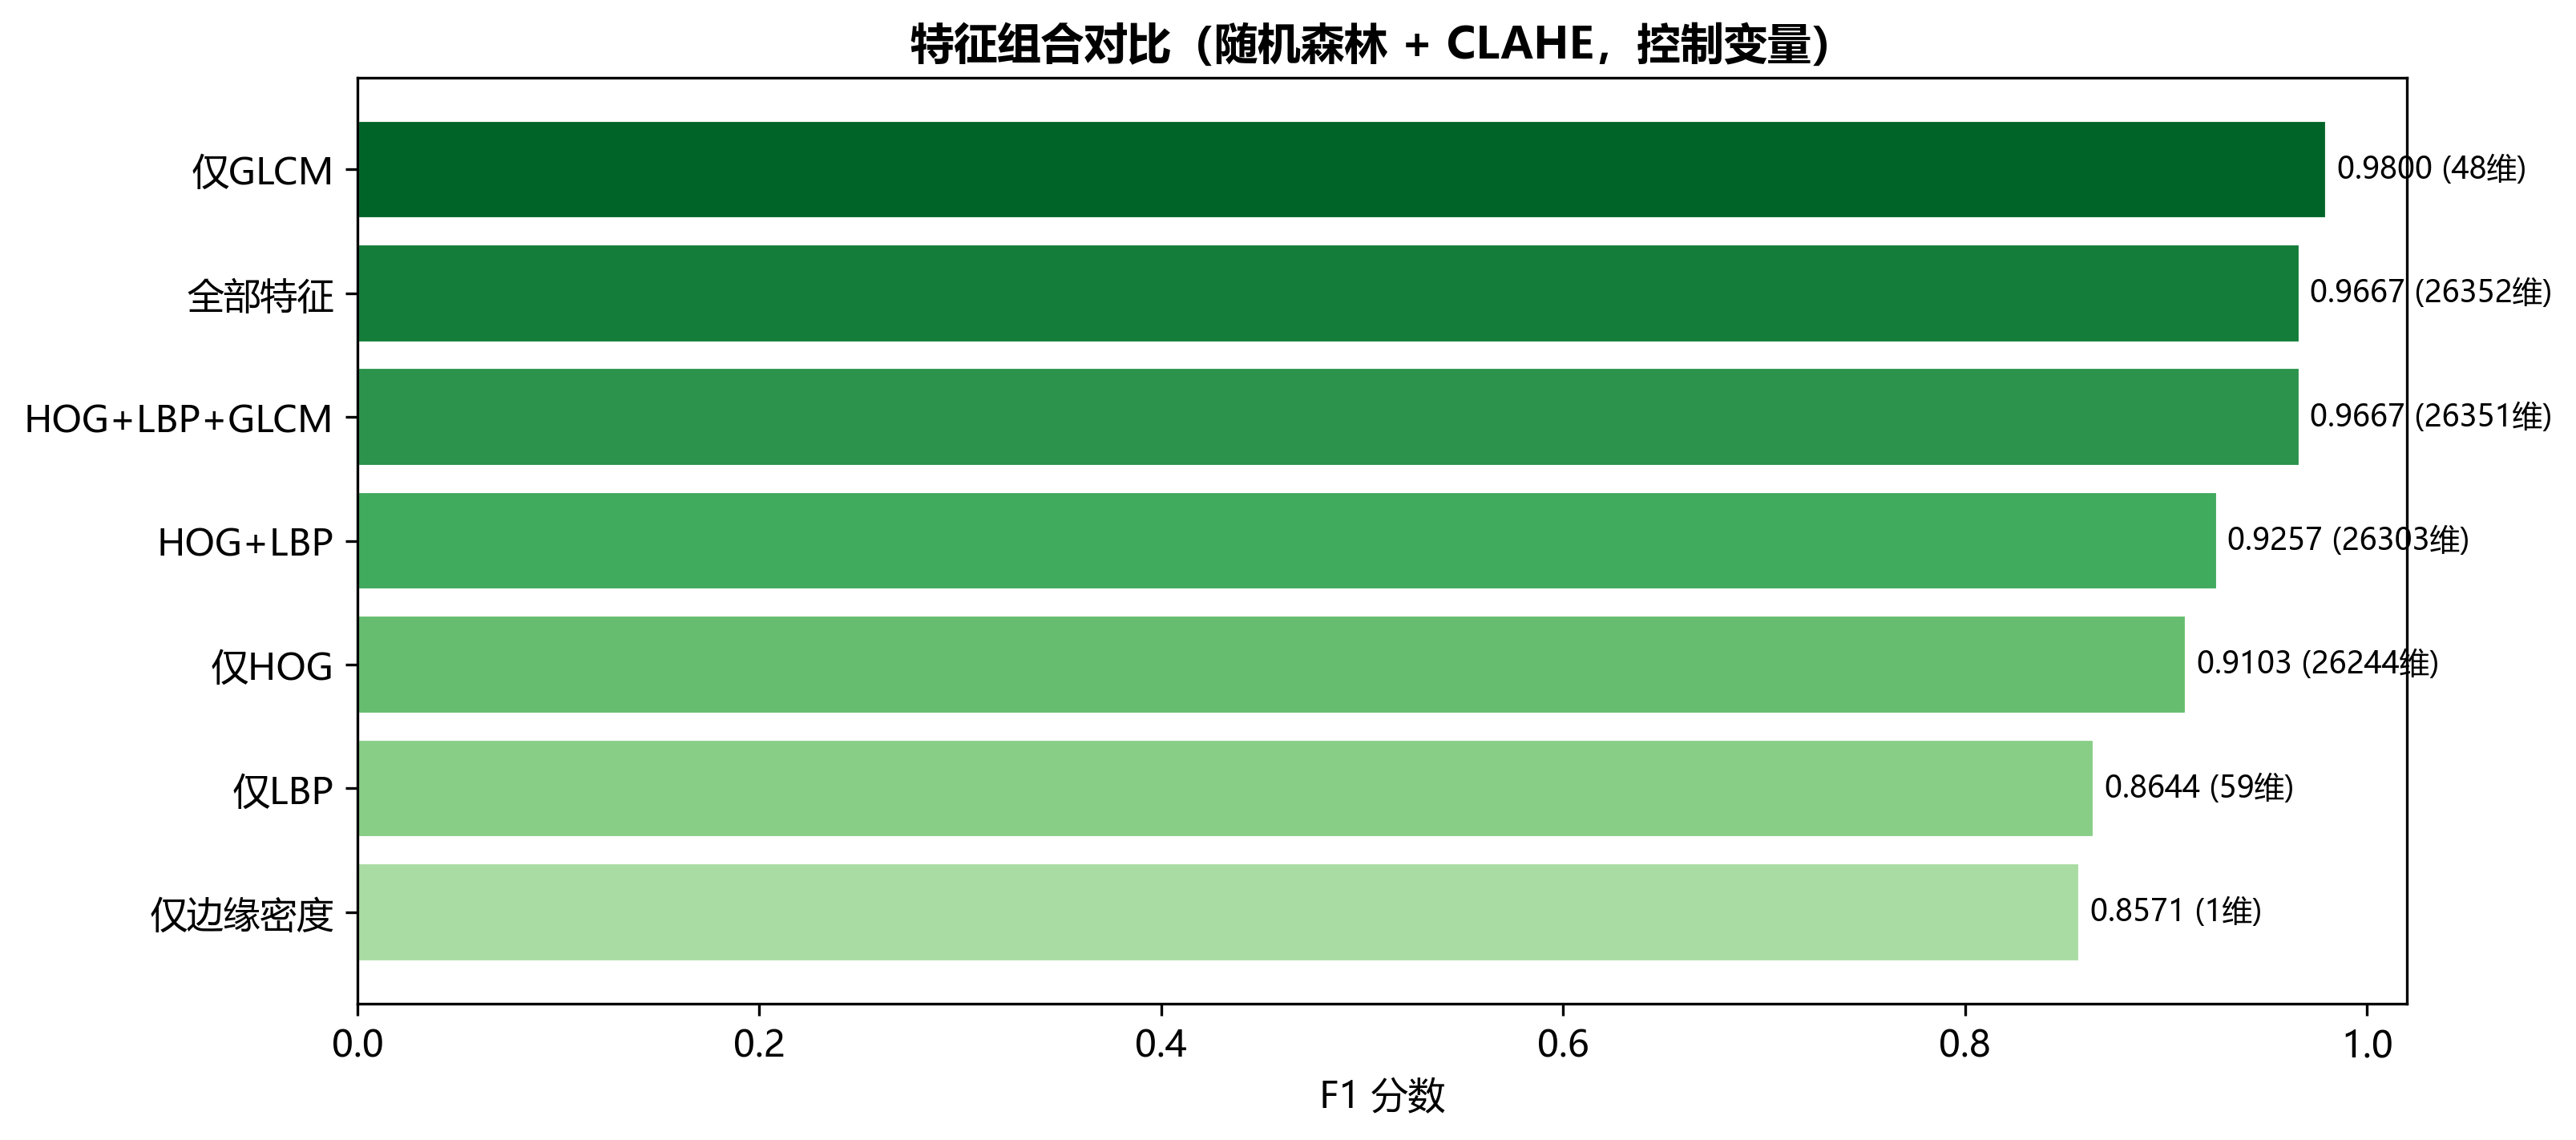

| 特征组合 | 维度 | Accuracy | F1 |
| --- | --- | --- | --- |
| 仅边缘密度 | 1 | 0.8538 | 0.8571 |
| 仅HOG | 26244 | 0.9136 | 0.9103 |
| 仅LBP | 59 | 0.8571 | 0.8644 |
| 仅GLCM | 48 | 0.9801 | 0.9800 |
| HOG+LBP | 26303 | 0.9269 | 0.9257 |
| HOG+LBP+GLCM | 26351 | 0.9668 | 0.9667 |
| 全部特征 | 26352 | 0.9668 | 0.9667 |

GLCM 单独使用时 F1 达到 **0.9800**，说明裂纹识别具有明显的纹理分类属性；HOG+LBP+GLCM 与全部特征均达到 **0.9667**，在稳健性上更适合后续统一模型对比。


## 四、传统监督模型训练链路

SVM、朴素贝叶斯、逻辑回归都需要先对特征做标准化，因此训练时使用 `Pipeline([("scaler", StandardScaler()), ("clf", model)])`。这样可以避免数据泄漏：标准化参数只在训练折上拟合，再应用到验证集或测试集。

模型训练使用 `GridSearchCV` 统一搜索超参数，并以 F1 作为主要优化指标。F1 同时考虑精确率和召回率，适合二分类任务中比较模型的综合分类能力。


In [ ]:
# 4. 模型构造与参数网格
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def build_traditional_model(model_name, params):
    if model_name == "svm":
        return SVC(
            kernel=params.get("kernel", "rbf"),        # kernel：核函数；linear 为线性边界，rbf 可学习非线性边界，poly 为多项式核。
            C=params.get("C", 1.0),                    # C：误分类惩罚系数；越大越重视训练集正确率，也越可能过拟合。
            gamma=params.get("gamma", "scale"),        # gamma：核函数影响范围；scale 会按特征维度和方差自动缩放。
            probability=True,                          # probability：启用概率输出，便于计算 ROC-AUC。
            random_state=params.get("random_state", 42), # random_state：固定内部随机过程，保证结果可复现。
        )

    if model_name == "naive_bayes":
        return GaussianNB(
            var_smoothing=params.get("var_smoothing", 1e-9)  # var_smoothing：给方差加上的平滑项，防止方差过小导致数值不稳定。
        )

    if model_name == "logistic_regression":
        lr_kwargs = {
            "C": params.get("C", 1.0),                  # C：正则化强度的倒数；越大正则越弱。
            "penalty": params.get("penalty", "l2"),     # penalty：正则化类型；l1 可产生稀疏权重，l2 更平滑稳定。
            "solver": params.get("solver", "lbfgs"),    # solver：优化算法；不同 solver 支持的 penalty 不同。
            "max_iter": 2000,                           # max_iter：最大迭代次数，避免高维特征下过早停止。
            "random_state": params.get("random_state", 42),
        }
        if lr_kwargs["penalty"] == "elasticnet":
            lr_kwargs["l1_ratio"] = params.get("l1_ratio", 0.5)  # l1_ratio：ElasticNet 中 L1 与 L2 的混合比例。
        return LogisticRegression(**lr_kwargs)

    raise ValueError(f"未知传统模型: {model_name}")

param_grids = {
    "svm": {
        "kernel": ["linear", "rbf", "poly"],  # 比较线性、径向基、多项式三种决策边界。
        "C": [0.1, 1, 10],                    # 从强正则到弱正则搜索。
        "gamma": ["scale", "auto"],           # scale 按数据自适应，auto 仅按特征数缩放。
    },
    "naive_bayes": {
        "var_smoothing": [1e-9, 1e-7, 1e-5, 1e-3],  # 搜索不同平滑强度。
    },
    "logistic_regression": [
        # lbfgs/liblinear/saga 均支持 l2，作为稳定基线。
        {"C": [0.01, 0.1, 1, 10, 100], "penalty": ["l2"], "solver": ["lbfgs", "liblinear", "saga"]},
        # l1 只由 liblinear/saga 支持，可产生稀疏权重。
        {"C": [0.01, 0.1, 1, 10, 100], "penalty": ["l1"], "solver": ["liblinear", "saga"]},
        # elasticnet 只由 saga 支持，用 l1_ratio 控制 L1/L2 混合比例。
        {"C": [0.01, 0.1, 1, 10, 100], "penalty": ["elasticnet"], "solver": ["saga"], "l1_ratio": [0.25, 0.5, 0.75]},
    ],
}


In [ ]:
# 5. 统一训练与评估函数
def fit_and_evaluate(model_name, data, cv_folds=3, scoring="f1"):
    X_tr, X_te = data["X_train"], data["X_test"]
    y_tr, y_te = data["y_train"], data["y_test"]

    base_model = Pipeline([
        ("scaler", StandardScaler()),              # StandardScaler：只在训练折拟合均值和方差，避免测试集信息泄漏。
        ("clf", build_traditional_model(model_name, {})),
    ])

    raw_grid = param_grids[model_name]
    if isinstance(raw_grid, list):
        # 逻辑回归需要分组网格，因为 solver 与 penalty 有兼容性限制。
        grid = [{f"clf__{k}": v for k, v in group.items()} for group in raw_grid]
    else:
        # Pipeline 中分类器步骤名为 clf，因此参数名前要加 clf__。
        grid = {f"clf__{k}": v for k, v in raw_grid.items()}

    search = GridSearchCV(
        estimator=base_model,  # estimator：待搜索的完整训练流水线。
        param_grid=grid,       # param_grid：候选超参数组合。
        cv=cv_folds,           # cv：交叉验证折数；3 折能在稳定性和耗时之间折中。
        scoring=scoring,       # scoring：以 F1 作为主要优化目标。
        n_jobs=-1,             # n_jobs=-1：使用全部 CPU 核心并行搜索。
        verbose=0,             # verbose=0：不输出搜索过程日志，保持报告整洁。
    )
    search.fit(X_tr, y_tr)

    y_pred = search.predict(X_te)
    y_prob = search.predict_proba(X_te)[:, 1]

    return {
        "model": model_name,
        "best_params": search.best_params_,
        "cv_f1": search.best_score_,
        "test_accuracy": accuracy_score(y_te, y_pred),
        "test_precision": precision_score(y_te, y_pred, zero_division=0),
        "test_recall": recall_score(y_te, y_pred, zero_division=0),
        "test_f1": f1_score(y_te, y_pred, zero_division=0),
        "test_auc": roc_auc_score(y_te, y_prob),
    }


## 五、方法一 · SVM

### 5.1 原理

支持向量机通过寻找最大间隔超平面进行分类。对于 HOG、LBP、GLCM 拼接后的高维特征，最大间隔思想有利于提升泛化能力。项目中 SVM 使用 `SVC(probability=True)`，这样可以输出正类概率并计算 ROC-AUC。

### 5.2 搜索空间与最优参数

```python
param_grid = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [0.1, 1, 10],
    "gamma": ["scale", "auto"],
}
```

全量实验最优参数：

```json
{
  "m__C": 0.1,
  "m__kernel": "linear"
}
```


In [ ]:
# 6. SVM 复现实验入口
if RUN_FULL_EXPERIMENT:
    svm_result = fit_and_evaluate("svm", data)
    svm_result
else:
    traditional_results[traditional_results["model"] == "svm"]


### 5.3 实验结果

| 指标 | 值 | 说明 |
|------|:--:|------|
| CV F1 | **0.9457** | 训练阶段 3 折交叉验证估计 |
| Test F1 | **0.9371** | 与逻辑回归持平 |
| Test ROC-AUC | **0.9865** | 概率判别能力较强 |
| 训练耗时 | **121.8 s** | 三个基础模型中最慢 |

SVM 的优势是高维空间分类边界稳定，劣势是训练成本较高；本项目全量训练耗时约 121.8 秒，因此更适合作为性能基线，而不是最轻量的部署方案。


## 六、方法二 · 朴素贝叶斯

### 6.1 原理

朴素贝叶斯基于贝叶斯公式，并假设特征之间条件独立：

$$
P(y|x) \propto P(y)\prod_i P(x_i|y)
$$

本项目使用 `GaussianNB` 处理连续手工特征。它训练极快，但 HOG、LBP、GLCM 等图像纹理特征之间并不真正独立，因此性能通常低于 SVM 和逻辑回归。

### 6.2 搜索空间与最优参数

```python
param_grid = {"var_smoothing": [1e-9, 1e-7, 1e-5, 1e-3]}
```

全量实验最优参数：

```json
{
  "m__var_smoothing": 1e-09
}
```


In [ ]:
# 7. 朴素贝叶斯复现实验入口
if RUN_FULL_EXPERIMENT:
    nb_result = fit_and_evaluate("naive_bayes", data)
    nb_result
else:
    traditional_results[traditional_results["model"] == "naive_bayes"]


### 6.3 实验结果

| 指标 | 值 | 说明 |
|------|:--:|------|
| CV F1 | **0.9059** | 训练阶段估计 |
| Test F1 | **0.9080** | 三者中最低 |
| Test ROC-AUC | **0.9478** | 仍具备一定排序能力 |
| 训练耗时 | **0.9 s** | 三者中最快 |

朴素贝叶斯的价值在于速度和简单性。它能够用极低成本给出一个可解释的概率基线，但由于独立性假设过强，无法充分刻画纹理特征之间的相关关系。


## 七、方法三 · 逻辑回归

### 7.1 原理

逻辑回归用 Sigmoid 函数把线性组合映射为正类概率：

$$
P(y=1|x)=\sigma(w^Tx+b)=\frac{1}{1+e^{-(w^Tx+b)}}
$$

它本质上学习一个线性决策边界。项目最优配置采用 L1 正则化，能够压缩不重要的特征权重，兼具分类与特征筛选作用。

### 7.2 搜索空间与最优参数

逻辑回归的 `solver` 与 `penalty` 存在兼容性约束，因此项目使用 list-of-dicts 格式分组搜索：

```python
param_grid = [
    {"C": [0.01, 0.1, 1, 10, 100], "penalty": ["l2"], "solver": ["lbfgs", "liblinear", "saga"]},
    {"C": [0.01, 0.1, 1, 10, 100], "penalty": ["l1"], "solver": ["liblinear", "saga"]},
    {"C": [0.01, 0.1, 1, 10, 100], "penalty": ["elasticnet"], "solver": ["saga"], "l1_ratio": [0.25, 0.5, 0.75]},
]
```

全量实验最优参数：

```json
{
  "m__C": 10,
  "m__penalty": "l1",
  "m__solver": "liblinear"
}
```


In [ ]:
# 8. 逻辑回归复现实验入口
if RUN_FULL_EXPERIMENT:
    lr_result = fit_and_evaluate("logistic_regression", data)
    lr_result
else:
    traditional_results[traditional_results["model"] == "logistic_regression"]


### 7.3 实验结果

| 指标 | 值 | 说明 |
|------|:--:|------|
| CV F1 | **0.9665** | 三者中最高 |
| Test F1 | **0.9371** | 与 SVM 持平 |
| Test ROC-AUC | **0.9911** | 三者中最高 |
| 训练耗时 | **3.2 s** | 明显快于 SVM |

逻辑回归在本项目中是基础传统监督模型的综合最优选择：它的 Test F1 与 SVM 相同，ROC-AUC 更高，训练耗时却只有 3.2 秒，并且模型权重具备可解释性。


## 八、三模型横向对比

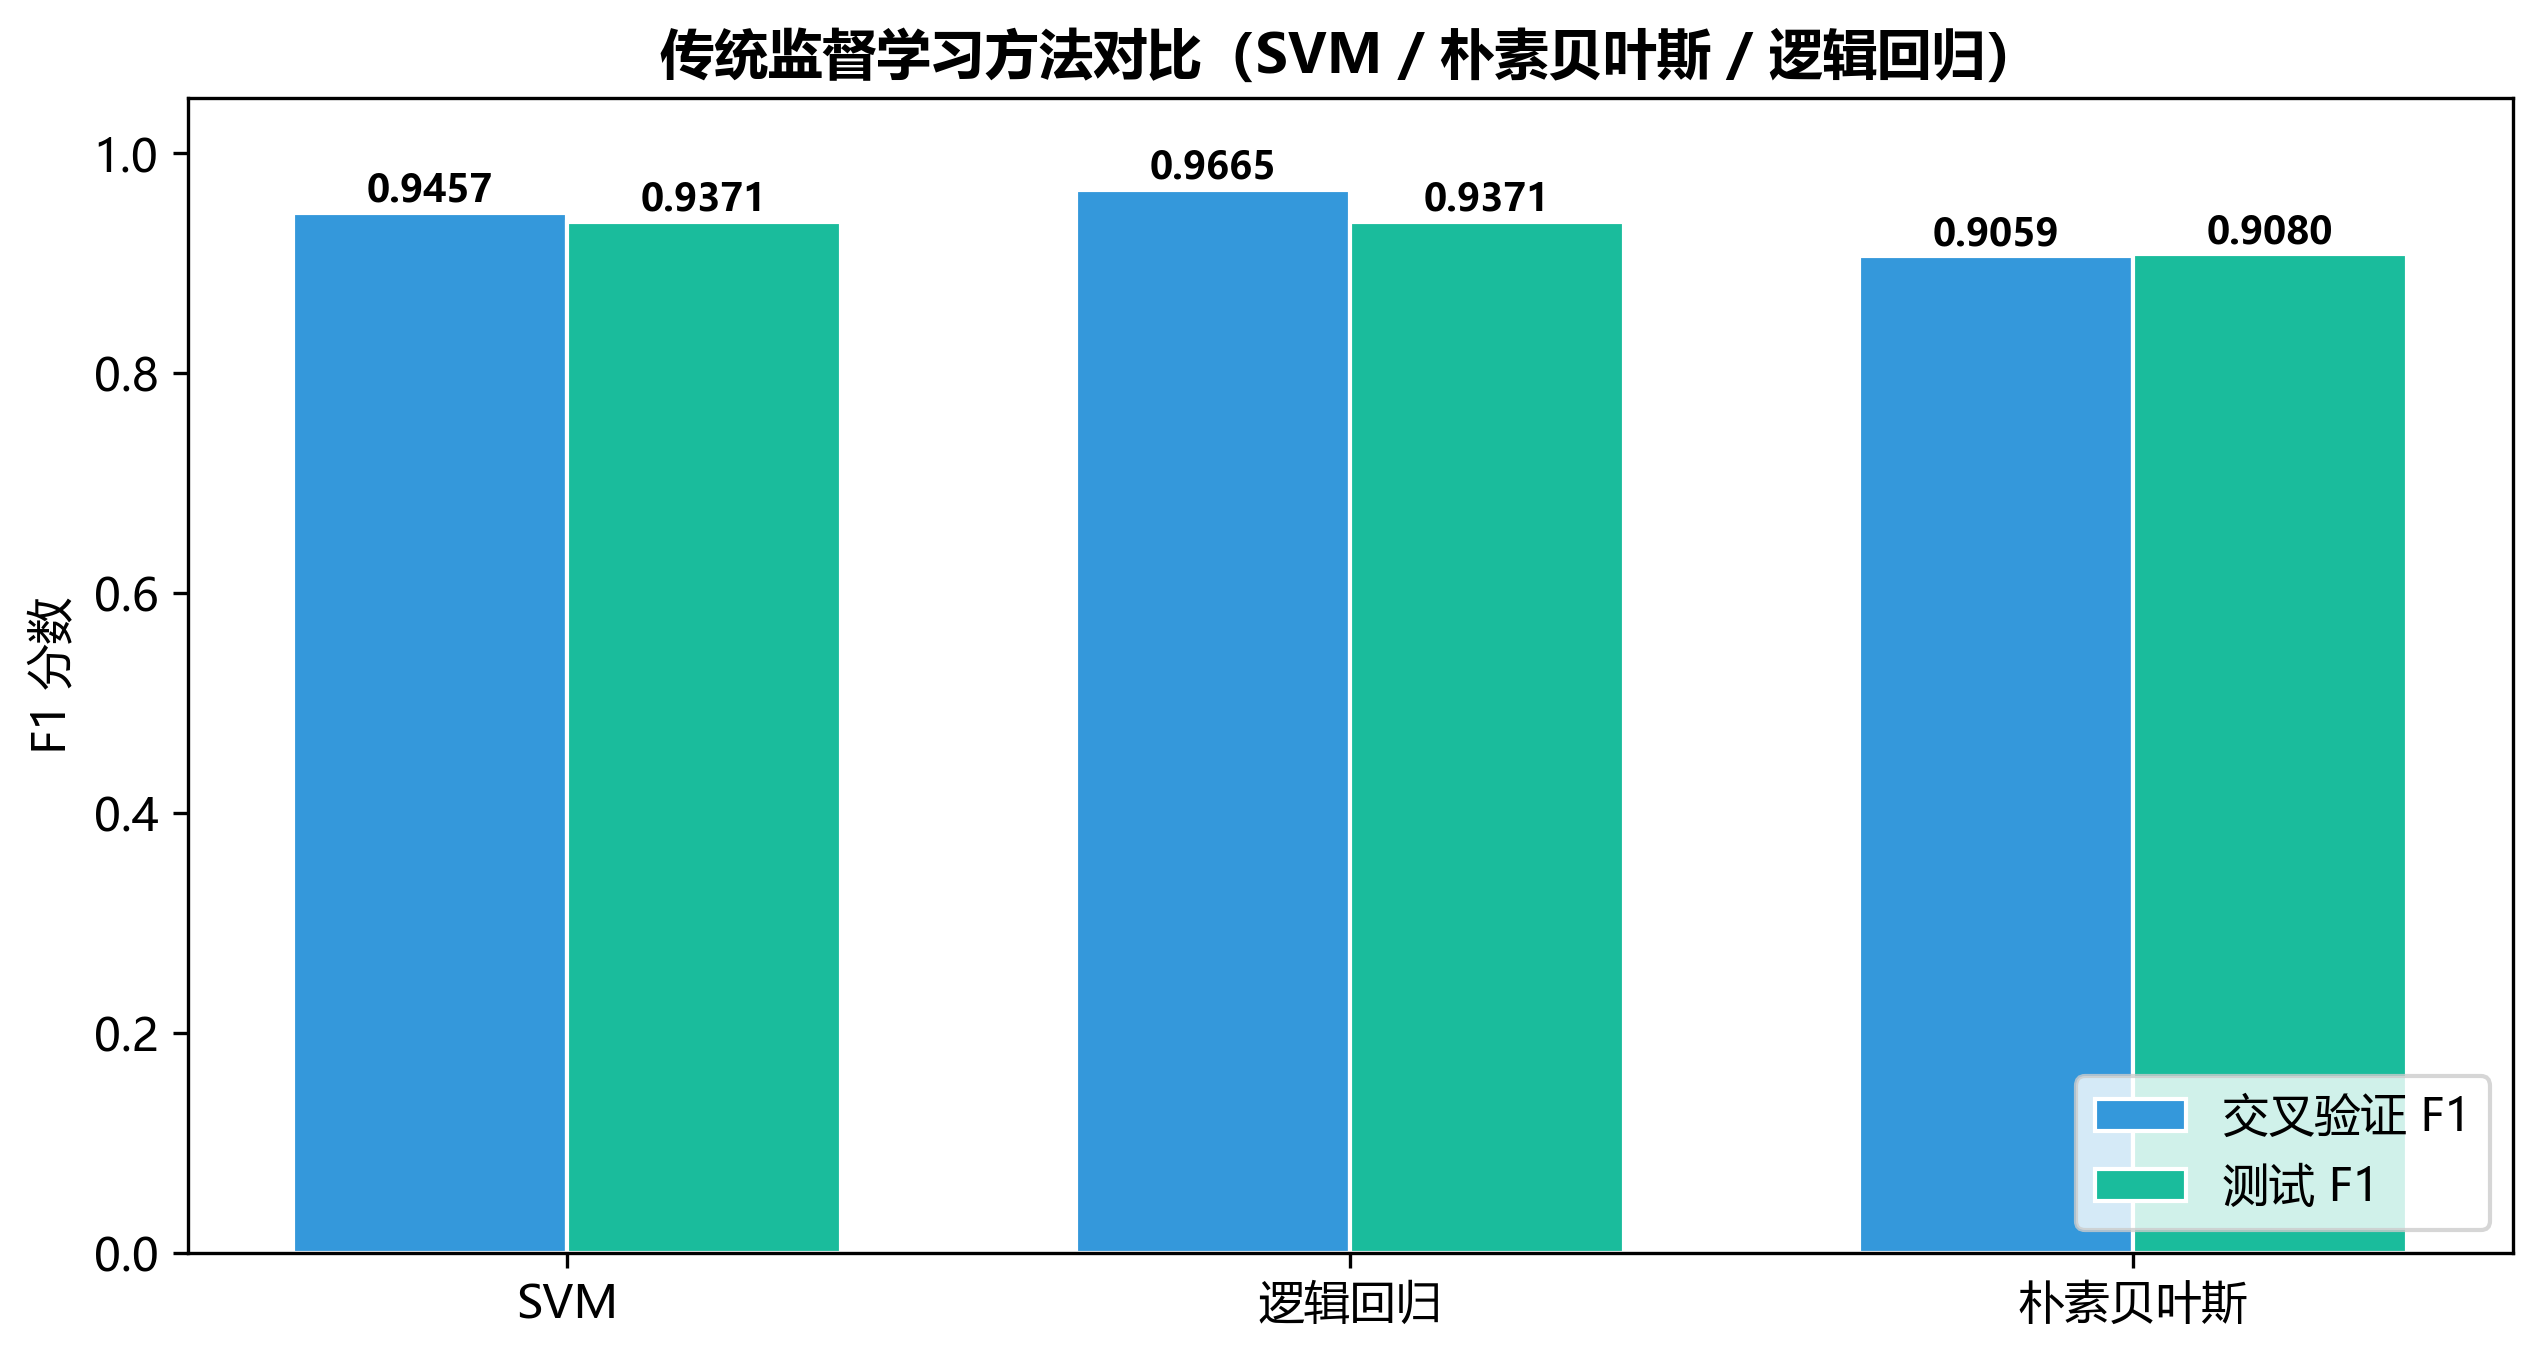

| 模型 | CV F1 | Test F1 | ROC-AUC | 训练耗时(s) | 最优参数 |
| --- | --- | --- | --- | --- | --- |
| SVM | 0.9457 | 0.9371 | 0.9865 | 121.8 | `C=0.1, kernel=linear` |
| 朴素贝叶斯 | 0.9059 | 0.9080 | 0.9478 | 0.9 | `var_smoothing=1e-9` |
| 逻辑回归 | 0.9665 | 0.9371 | 0.9911 | 3.2 | `C=10, penalty=l1, solver=liblinear` |

### 8.1 方法选择建议

- **追求稳定高维分类边界**：选择 SVM，但要接受训练时间较长。
- **追求极快训练和简单概率基线**：选择朴素贝叶斯，但性能上限较低。
- **追求性能、速度、解释性平衡**：选择逻辑回归，本项目中综合性价比最高。

这三个模型共同构成传统监督学习的基础基线：在合理的数据处理与手工特征工程支持下，非深度模型已经可以达到约 **0.91–0.94** 的 Test F1，为后续树模型、集成学习和 CNN 提供了可比较的参考。


In [ ]:
# 9. 最终汇总表：只保留本报告负责的三个模型
focus_models = ["svm", "naive_bayes", "logistic_regression"]
traditional_results[traditional_results["model"].isin(focus_models)].sort_values(
    "test_f1", ascending=False
)


## 九、本部分总结

本部分完成了“原始图像 → 数据处理 → 特征工程 → 传统监督分类”的完整代码链路整合：

1. 数据读取阶段解决 Windows 中文路径与正负样本标签构造问题。
2. 预处理阶段通过 CLAHE、滤波等方法增强裂纹纹理与边缘。
3. 特征工程阶段将图像转换为 HOG、LBP、GLCM、边缘密度组成的高维向量。
4. 数据划分阶段使用分层思想，保证训练/测试评估稳定。
5. 模型阶段通过 Pipeline 防止标准化数据泄漏，并用 GridSearchCV 统一搜索参数。
6. 结果层面，逻辑回归综合表现最好，SVM 作为强基线稳定，朴素贝叶斯作为轻量基线速度最快。

后续如果继续优化传统监督方法，可以优先考虑：对 GLCM/HOG 特征做选择或降维；对逻辑回归权重做可解释性分析；或进一步引入随机森林、XGBoost、LightGBM 等非线性集成方法提升性能。
